<a href="https://colab.research.google.com/github/epythonlab2/AI_4_health/blob/main/module_2_unsupervised_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<header style="font-family: 'Inter', sans-serif; background: #ffffff; padding: 16px; border-radius: 8px; border: 1px solid #e1e4e8; display: flex; align-items: center; gap: 12px; box-shadow: 0 2px 8px rgba(0,0,0,0.05); margin-bottom: 10px;">
    <div style="width: 4px; height: 35px; background: linear-gradient(to bottom, #4e73df, #1cc88a); border-radius: 2px;"></div>
    <h1 style="color: #1a1a1a; margin: 0; font-size: 20px; font-weight: 700; border: none;">Module 2: Machine Learning and Statistics</h1>
</header>

<div style="font-family: 'Inter', sans-serif; max-width: 900px; margin: 15px 0; padding: 20px; border-radius: 10px; background: #f1f4ff; border: 1px solid #dbe3ff; display: flex; align-items: center; justify-content: space-between; gap: 15px;">
    <div style="flex: 1;">
        <h2 style="margin: 0; color: #2e59d9; font-size: 18px; font-weight: 700; border: none;">Chapter 3: Unsupervised Learning & Feature Engineering</h2>
        <span style="display: inline-block; margin-top: 8px; background: #ffffff; padding: 4px 12px; border-radius: 6px; color: #4e73df; font-weight: 800; font-size: 11px; border: 1px solid #dbe3ff; text-transform: uppercase;">12 Hours</span>
    </div>

   <a href="https://linkedin.com/in/dejenet" target="_blank" style="background-color: #0077b5; color: white; padding: 10px 20px; border-radius: 8px; text-decoration: none; font-size: 14px; font-weight: 700; white-space: nowrap;">
        Connect on LinkedIn
    </a>
</div>

**1. Big Picture: Supervised vs Unsupervised Learning**

####**1.1 What Problem Are We Solving?**

In the real world, "labels" (the answers) are expensive. They require human experts, time, and money. Unsupervised learning solves the **Cold Start Problem**: understanding your data before you have a target variable.

- **Customer Segmentation:** Grouping users by behavior (e.g., "Big Spenders" vs. "Window Shoppers") to tailor marketing.

- **Fraud Pattern Discovery:** You don't know what the next fraud looks like, but you can see what looks different from the norm.

- **Feature Discovery:** Using algorithms like PCA to compress 100 messy variables into 5 clean, highly informative ones.

####**1.2 Supervised vs Unsupervised(Conceptual)**

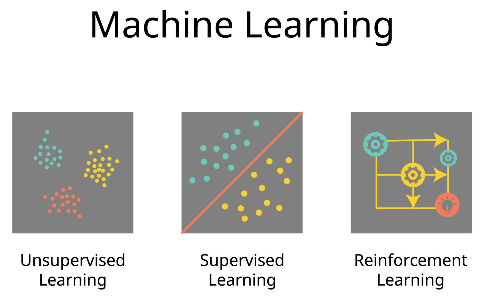

<table border="1" style="width:100%; border-collapse: collapse; text-align: left;">
    <thead>
        <tr style="background-color: #f2f2f2;">
            <th style="padding: 12px;">Feature</th>
            <th style="padding: 12px;">Supervised Learning</th>
            <th style="padding: 12px;">Unsupervised Learning</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 10px;"><strong>Input Data</strong></td>
            <td style="padding: 10px;">Features + Labels (<code>X and y</code>)</td>
            <td style="padding: 10px;">Features only (<code>X</code>)</td>
        </tr>
        <tr>
            <td style="padding: 10px;"><strong>Goal</strong></td>
            <td style="padding: 10px;">Predict a specific target</td>
            <td style="padding: 10px;">Find hidden patterns/structure</td>
        </tr>
        <tr>
            <td style="padding: 10px;"><strong>Feedback</strong></td>
            <td style="padding: 10px;">Direct (Loss functions / Accuracy)</td>
            <td style="padding: 10px;">Indirect (Cluster density / Variance)</td>
        </tr>
        <tr>
            <td style="padding: 10px;"><strong>Analogy</strong></td>
            <td style="padding: 10px;">A student with a textbook and an answer key.</td>
            <td style="padding: 10px;">A student exploring a museum without a tour guide.</td>
        </tr>
    </tbody>
</table>

####**1.3 Where Unsupervised Fits in ML Pipelines**

**1. Pre-processing: Feature Discovery & Engineering**

Before feeding data into a supervised model, unsupervised techniques are used to clean and simplify the input.

- **Dimensionality Reduction:** Using algorithms like **PCA** to merge 50 correlated variables into 5 "principal" ones. This prevents the "curse of dimensionality" and speeds up training.

- **Grouping Features:** Identifying which features behave similarly to create more meaningful aggregate variables.

**2. Standalone Analysis (Exploratory Data Analysis)**

Sometimes, the goal isn't to predict the future, but to understand the present.

- **Market Basket Analysis:** Figuring out that people who buy diapers also tend to buy beer.

- **Persona Creation:** Grouping a database of 1 million users into 4 distinct personas based on usage habits.

**3. Production Systems: Monitoring & Drift Detection**

Once a supervised model is deployed, unsupervised learning acts as a "security guard."

- **Data Drift:** An unsupervised model monitors the incoming live data. If the distribution of that data shifts significantly from the training data, it triggers an alert.

- **Outlier Detection:** Identifying "novelty" in data—like a sudden spike in traffic from a specific region—that the supervised model isn't trained to handle.

####**1.4 Hands-on: Transaction Dataset Exploration**

When you load a dataset (like a CSV of Customer Spending), you initially ignore any **"Label"** columns. Your goal is to look at the raw features ($X$) and find the "skeleton" of the data.

Download [Customer Spending Dataset](https://www.kaggle.com/datasets/goyaladi/customer-spending-dataset) from Kaggle

In [1]:
from google.colab import files
import os

# # 1. Upload the kaggle.json file you just downloaded
# files.upload()

# # 2. Set up the Kaggle directory
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

# # 3. Download and unzip the dataset
# !kaggle datasets download -d goyaladi/customer-spending-dataset
# !unzip customer-spending-dataset.zip

# 4. Load the data
import pandas as pd
df = pd.read_csv('customer_data.csv', encoding='ISO-8859-1')

In [2]:
# Explore the data
df.head()

,name,age,gender,education,income,country,purchase_frequency,spending
0,Teresa Williams MD,42,Female,High School,53936,Slovenia,0.9,13227.120
1,Christine Myers,49,Female,Master,82468,Aruba,0.6,12674.040
2,Dwayne Moreno,55,Male,Bachelor,56941,Cyprus,0.3,5354.115
3,Amy Norton,24,Female,Bachelor,60651,Palau,0.2,2606.510
4,Tonya Adams,64,Male,Master,81884,Zambia,0.9,18984.780


At this stage, you’re just asking:
What does one row represent?

Usually the answer is: **one customer over a time period or one transaction event**.

**Explore columns without labels (no explanations yet)**

Before defining anything, inspect structure and types.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                1000 non-null   object 
 1   age                 1000 non-null   int64  
 2   gender              1000 non-null   object 
 3   education           1000 non-null   object 
 4   income              1000 non-null   int64  
 5   country             1000 non-null   object 
 6   purchase_frequency  1000 non-null   float64
 7   spending            1000 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


**Key things to notice:**

- **Number of rows** → how many customers or events?

- **Data types** → numeric vs categorical

- **Missing values** → Where might gaps exist?

In [4]:
# Understand the features(X)
df.columns

Index(['name', 'age', 'gender', 'education', 'income', 'country',
       'purchase_frequency', 'spending'],
      dtype='object')

<table border="1" style="width:100%; border-collapse: collapse; text-align: left; font-family: sans-serif;">
    <thead>
        <tr style="background-color: #e0e0e0;">
            <th style="padding: 12px;">Column Name</th>
            <th style="padding: 12px;">Data Type</th>
            <th style="padding: 12px;">Action for Clustering</th>
            <th style="padding: 12px;">Reasoning</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 10px;"><strong>name</strong></td>
            <td style="padding: 10px;">Unique String</td>
            <td style="padding: 10px; color: #d9534f;"><strong>Drop (Selection)</strong></td>
            <td style="padding: 10px;">Unique identifiers have no mathematical pattern.</td>
        </tr>
        <tr>
            <td style="padding: 10px;"><strong>age, income, spending</strong></td>
            <td style="padding: 10px;">Numerical</td>
            <td style="padding: 10px; color: #5bc0de;"><strong>Scale (StandardScaler)</strong></td>
            <td style="padding: 10px;">Ensures large income numbers don't drown out age.</td>
        </tr>
        <tr>
            <td style="padding: 10px;"><strong>gender, country</strong></td>
            <td style="padding: 10px;">Nominal Categorical</td>
            <td style="padding: 10px; color: #f0ad4e;"><strong>One-Hot Encoding</strong></td>
            <td style="padding: 10px;">Creates binary 1/0 columns (e.g., is_UK, is_USA).</td>
        </tr>
        <tr>
            <td style="padding: 10px;"><strong>education</strong></td>
            <td style="padding: 10px;">Ordinal Categorical</td>
            <td style="padding: 10px; color: #5cb85c;"><strong>Label/Ordinal Encoding</strong></td>
            <td style="padding: 10px;">Preserves the rank (e.g., High School &lt; Masters).</td>
        </tr>
        <tr>
            <td style="padding: 10px;"><strong>purchase_frequency</strong></td>
            <td style="padding: 10px;">Numerical / Ratio</td>
            <td style="padding: 10px; color: #5bc0de;"><strong>Scale</strong></td>
            <td style="padding: 10px;">Standardizes the behavior "signal" for distance.</td>
        </tr>
    </tbody>
</table>

In [5]:
# Check the rows and columns
df.shape

(1000, 8)

In [6]:
# Check missing values
df.isna().sum()

,0
name,0
age,0
gender,0
education,0
income,0
country,0
purchase_frequency,0
spending,0


**1. Ask the key question:** “What patterns might exist here?”

Without defining anything, you can already explore:

**Demographic patterns**

- Does spending change with age?

- Does income scale linearly with spending?

**Behavioral segmentation**

- High purchase frequency + low spending?

- Low frequency + high spending?

**Group differences**

- Spending differences by education level

- Purchase frequency across countries

**Outliers**

- Very high income, very low spending

- Very young age with unusually high spending

**2. What this dataset is naturally good for**

Even unlabeled, this is perfect for:

- Customer segmentation

- Behavioral profiling

- Marketing analysis

- Clustering

- Simple regression exploration

**3. Mental summary (important)**

Without knowing the story, you can still say:

> This dataset describes people and how they spend, combining demographics with purchasing behavior.

That’s enough to start real analysis.

### **2. Introduction to Clustering**



#### **2.1 What Is Clustering Really Doing?**

At its core, clustering is about **finding patterns in** **similarity**.

The algorithm looks at your data and asks a simple question:**Which observations behave alike?**

It doesn’t care about labels, outcomes, or correctness. It only measures distance, similarity, or density and then groups points that “feel close” to each other based on those rules.

**1. Grouping Similar Behaviors**

Clustering groups data points that show **similar behavior**, not identical values.

For example:

- Customers with similar spending habits

- Transactions with similar amounts and timing

- Patients with similar health measurements

Two points end up in the same cluster because their overall patterns match, even if no single feature is exactly the same.

This is why clustering is powerful in exploratory analysis. It helps you discover structure you didn’t explicitly define.

**2. No “Right or Wrong” Answers**

Unlike supervised learning, clustering has:

- No ground truth labels

- No correct output to compare against

Different algorithms can produce different clusters from the same data, and **that’s normal**.

**K-Means, DBSCAN, and Hierarchical Clustering** are not competing to find the “true” clusters. They are answering **different questions** about the data.

So instead of asking:

> Is this clustering correct?

The better question is:

> Is this clustering useful for my problem?




**3. Clusters Are Hypotheses, Not Truths**

A cluster is not a fact. It’s a **hypothesis**.

When an algorithm creates a cluster, it’s essentially saying:

> These points might belong together based on the rules I used.

It’s up to you to:

- Interpret the clusters

- Validate them with domain knowledge

- Decide whether they make sense in context

In practice, clusters often lead to **questions**, not answers:

- Why do these customers behave differently?

- What separates this group from the others?

- Should this cluster be treated differently in a business or policy decision?

**Key takeaway:**
Clustering doesn’t discover truth. It proposes structure.

Your job is to judge whether that structure is meaningful, useful, and defensible in the real world.

####**2.2 Common Clustering Use Cases in Finance**

**Clustering** is widely used in finance because many important patterns are **not** **labeled in advance**. We often don’t know who is risky, loyal, or abnormal until we explore the data.

**1. Spending Behavior Segmentation**

Banks and fintech companies cluster customers based on how they spend money, not who they are.

Typical features include:

- Transaction amounts

- Frequency of purchases

- Merchant categories

- Time and location patterns

This helps answer questions like:

- Who are high-value customers?

- Who spends steadily vs irregularly?

- Which users are price-sensitive or impulsive?

These segments drive personalized offers, credit limits, and product design.

**2. Risk Profiling**

Clustering is often used as a **pre-risk step**, before any predictive model.

By clustering customers or transactions, institutions can identify:

- Low-risk, stable behavior patterns

- Medium-risk groups with emerging volatility

- Unusual or rare behavior that deserves closer monitoring

Importantly, clustering does not label someone as “**fraudulent**” or “**default-prone**.”

It flags **behavioral similarity**, which analysts then investigate further.

**3. Customer Lifecycle Analysis**

Customers change over time. Clustering helps track where they are in **their financial journey**.

Common lifecycle clusters include:

- New users learning the platform

- Active and growing customers

- Stable, mature customers

- Dormant or declining users

By clustering behavior across time windows, companies can:

- Detect early churn signals

- Design retention strategies

- Target re-engagement campaigns

**Key takeway:** In finance, clustering is not about prediction. It’s about **understanding structure in behavior** so better decisions can follow.

###**3. Distance Metrics (High-Level)**

To understand how clustering works, you have to understand **distance**. If clustering is about "grouping similar things," distance is the ruler we use to measure that "**similarity**."

In a 2D space, distance is **intuitive**. In high-dimensional data (like a customer profile with 50 different variables), distance becomes the **mathematical language of relationshi**p.

####**3.1 Euclidean Distance:** **"The Bird’s Flight"**

This is the most common metric. It is the straight-line distance between two points. It’s best when your data is dense and continuous (like height, weight, or salary). In a 2D plane, the distance $d$ between points $(x_1, y_1)$ and $(x_2, y_2)$ is:$$d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$

**Pros:** Intuitive and works for most physical-world problems.

**Cons:** Very sensitive to outliers and scale (if one variable is in "meters" and another in "kilometers," the kilometers will dominate the calculation)

**Example:** Try this thought experiment:

1. Point $A: (0, 0) -> (x_1, y_1)$

2. Point $B: (3, 4) -> (x_2, y_2)$

Euclidean Distance: $\sqrt{3^2 + 4^2} = 5$ units.

####**3.2 Manhattan Distance: "The Taxicab"**

Imagine you are in a city laid out in a grid. You can't walk through buildings; you have to follow the streets. Manhattan distance sums the absolute differences of their coordinates.$$d = |x_2 - x_1| + |y_2 - y_1|$$

**Pros:** More robust than Euclidean when you have "high-dimensional" data or many outliers.

**Cons:** It can feel less "natural" in physical space since it ignores the diagonal shortcut.

**Example:** Try this thought experiment:

1. Point $A: (0, 0) -> (x_1, y_1)$

2. Point $B: (3, 4) -> (x_2, y_2)$

Manhattan Distance: $|3-0| + |4-0| = 7$ units.

**3. Why the Choice Matters**

The metric you choose acts as a lens. It changes how the algorithm perceives "**closeness**," which fundamentally reshapes the clusters.

<table style="width:100%; border-collapse: collapse; font-family: sans-serif;">
  <thead>
    <tr style="background-color: #f2f2f2; text-align: left;">
      <th style="padding: 12px; border: 1px solid #ddd;">Metric</th>
      <th style="padding: 12px; border: 1px solid #ddd;">Impact on Clustering</th>
      <th style="padding: 12px; border: 1px solid #ddd;">Geometric Intuition</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 12px; border: 1px solid #ddd;"><strong>Euclidean</strong></td>
      <td style="padding: 12px; border: 1px solid #ddd;">Tends to create <strong>spherical (round)</strong> clusters. It wants to find a "center" and group everything around it equally.</td>
      <td style="padding: 12px; border: 1px solid #ddd;">"As the crow flies" (Straight line)</td>
    </tr>
    <tr>
      <td style="padding: 12px; border: 1px solid #ddd;"><strong>Manhattan</strong></td>
      <td style="padding: 12px; border: 1px solid #ddd;">Tends to create <strong>square or diamond-shaped</strong> clusters. Better when features are independent or discrete.</td>
      <td style="padding: 12px; border: 1px solid #ddd;">"City block" distance (L-shaped paths)</td>
    </tr>
  </tbody>
</table>

**Reading: Cosine Similarity**

**Hands-on:** Search for **Customer Spending Dataset** on Kaggle

In [7]:
import kagglehub
path = kagglehub.dataset_download("goyaladi/customer-spending-dataset")

Using Colab cache for faster access to the 'customer-spending-dataset' dataset.


In [8]:
import os

# List files in the downloaded path
print(os.listdir(path))
# Construct the full file path
# This dynamically joins the folder path with the specific CSV name
csv_path = os.path.join(path, "customer_data.csv")

['customer_data.csv']


In [9]:
import pandas as pd
# Read the data
df = pd.read_csv(csv_path)

# View the first few rows
df.head()

,name,age,gender,education,income,country,purchase_frequency,spending
0,Teresa Williams MD,42,Female,High School,53936,Slovenia,0.9,13227.120
1,Christine Myers,49,Female,Master,82468,Aruba,0.6,12674.040
2,Dwayne Moreno,55,Male,Bachelor,56941,Cyprus,0.3,5354.115
3,Amy Norton,24,Female,Bachelor,60651,Palau,0.2,2606.510
4,Tonya Adams,64,Male,Master,81884,Zambia,0.9,18984.780


In [10]:
df.shape

(1000, 8)

In [11]:
# Rename columns
# df.columns = ['gender', 'age', 'income', 'spending_score']

In [12]:
# 1. Select the best columns for Euclidean distance
features = ['income', 'spending']
X = df[features]

In [13]:
from sklearn.preprocessing import StandardScaler
# 2. SCALE THE DATA (Crucial for Euclidean!)
# This makes $50,000 income comparable to a 75/100 spending score
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
X_scaled[:5]

array([[-0.22978925,  0.6592205 ],
       [ 0.99756538,  0.55832966],
       [-0.10052384, -0.77694449],
       [ 0.0590684 , -1.27815261],
       [ 0.97244358,  1.70951193]])

###**4. K-Means Clustering (Deep Dive)**

####**4.1 How K-Means Works (Intuition First)**

**K-Means** is about **finding centers and pulling similar points toward the same center**. It repeats a simple loop until things stop changing.

**1. Centroids**

A **centroid** is the “center” of a cluster.
Think of it as the average location of all points in that group.

At the start, centroids are usually placed **randomly**. They are just guesses.

**2. Assignment Step**

Each data point asks a simple question:

> Which centroid am I closest to?

Using a distance metric (usually Euclidean), every point is assigned to its nearest centroid.
This forms temporary clusters.

**3. Update Step**

Now the centroids move.

For each cluster:

- Take all points assigned to it

- Compute their mean (average position)

- Move the centroid to that new location

This makes the centroid better represent its cluster.

**4. Iterative Improvement**

Steps 2 and 3 repeat:

- Assign points to the nearest centroid

- Update centroid positions

With each iteration:

- Points become more tightly grouped

- Centroids stabilize

- Overall distance within clusters decreases

The algorithm stops when:

- Centroids stop moving (or move very little)

- Assignments no longer change

- A maximum number of iterations is reached

In [15]:
from sklearn.cluster import KMeans

# 3. Run K-Means (which uses Euclidean distance by default)
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,name,age,gender,education,income,country,purchase_frequency,spending,cluster
0,Teresa Williams MD,42,Female,High School,53936,Slovenia,0.9,13227.120,3
1,Christine Myers,49,Female,Master,82468,Aruba,0.6,12674.040,4
2,Dwayne Moreno,55,Male,Bachelor,56941,Cyprus,0.3,5354.115,2
3,Amy Norton,24,Female,Bachelor,60651,Palau,0.2,2606.510,2
4,Tonya Adams,64,Male,Master,81884,Zambia,0.9,18984.780,4


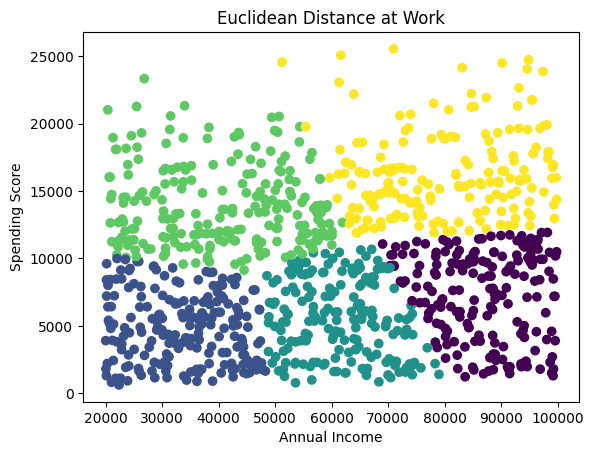

In [16]:
import matplotlib.pyplot as plt
# 4. Visualize the "Seams"
plt.scatter(df['income'], df['spending'], c=df['cluster'], cmap='viridis')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Euclidean Distance at Work')
plt.show()

####**4.2 Choosing K**

Choosing **K** means deciding how many clusters you want the data split into.
There is no automatic answer. You’re balancing structure, simplicity, and usefulness.

**1. Elbow Method**

**Idea:**
As **K** increases, clusters become smaller and tighter. But after a point, the improvement slows down.

**How it works:**

- Run K-Means for different values of K (e.g., 1 to 10)

- For each K, compute within-cluster sum of squares (WCSS)
(how far points are from their centroids)

- Plot K vs WCSS

**What to look for:**

- A sharp drop at first

- Then a point where the curve bends and flattens
→ this bend is the “elbow”

That K is a reasonable choice.

**Intuition:**
Adding clusters helps a lot at first. After the elbow, you’re just over-splitting.

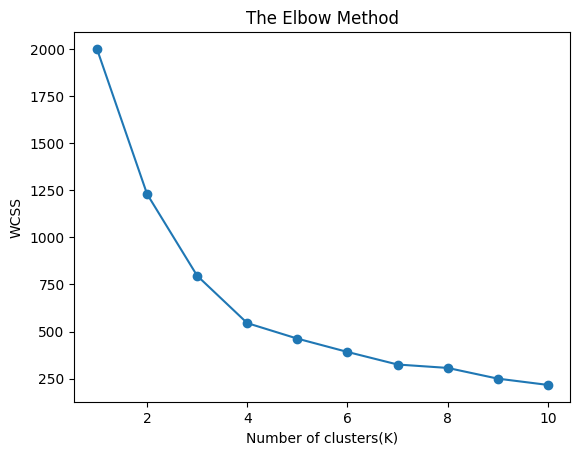

In [17]:
# 1. Calculate WCSS for K = 1 to 10
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# 2. Plot K vs WCSS
plt.plot(range(1, 11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters(K)')
plt.ylabel('WCSS')
plt.show()

**2. Silhouette Score**

**Idea:**
Measures how well each point fits inside its cluster compared to others.

**For each point:**

- a = average distance to points in the same cluster

- b = average distance to points in the nearest other cluster

$$\text{Silhouette score:} \frac {b - a} {max(a, b)}$$

**Range:**

- Close to +1 → well clustered

- Around 0 → overlapping clusters

- Negative → likely in the wrong cluster

**How to use it:**

- Compute average silhouette score for different K values

- Choose the K with the highest score

**Intuition:**
Good clusters are:

- Tight inside

- Far from each other

In [18]:
from sklearn.metrics import silhouette_score
silhouette_scores = []

for k in range(2, 11):  # silhouette needs at least 2 clusters
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

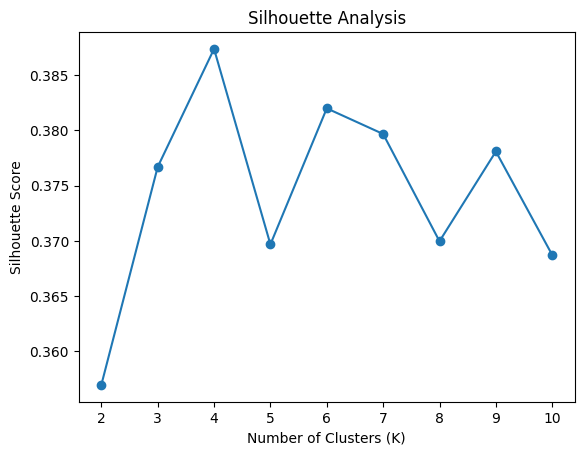

In [19]:
plt.figure()
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()


👉 Higher score = better cluster separation.

`fit()` → learn centroids

`predict()` → assign clusters

`fit_predict()` → both at once

`inertia`_ → WCSS (Elbow)

`silhouette_score()` → cluster quality

**3. Why There Is No “Perfect K”**

Because data doesn’t come with labels saying “I have 3 clusters”.

**Main reasons:**

- Real-world data is messy and overlapping

- Different K values can be valid for different goals

- Business or domain meaning matters more than metrics

- K-Means assumes spherical, equally sized clusters (often false)

**Example:**
**Customer data:**

- K = 3 → high, medium, low spenders

- K = 6 → more detailed behavior groups

Both can be “correct” depending on the use case.

**Key Takeaway**

Choosing K is a **decision**, not a formula.

- Elbow → trade-off between simplicity and fit

- Silhouette → cluster quality

- Domain knowledge → final judge

**Final K-Means Model (Chosen K)**

**The optimal value of K = 4:**

In [20]:
kmeans = KMeans(
    n_clusters=4,
    init="k-means++",
    n_init=10,
    random_state=42
)

labels = kmeans.fit_predict(X_scaled)
centroids = kmeans.cluster_centers_

# Update the old cluster column by the new optimal cluster
df['cluster'] = labels

In [21]:
centroids

array([[ 0.80440678, -0.66026423],
       [-0.80257635,  0.76506822],
       [ 0.9592952 ,  1.0932834 ],
       [-0.89881448, -0.85528656]])

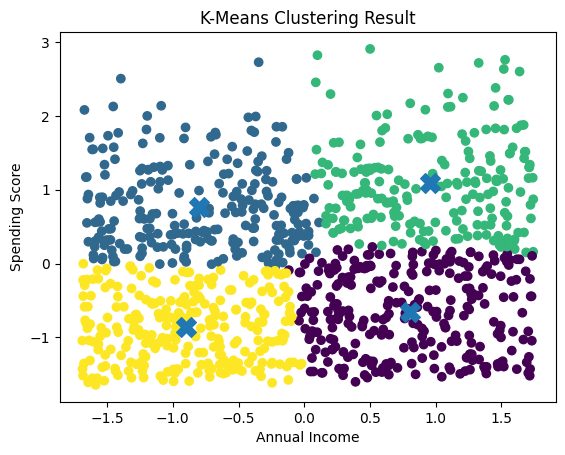

In [22]:
# Visualize the cluster
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=200,
    marker='X'
)
plt.title("K-Means Clustering Result")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()


**Key Insight:**
- Elbow and silhouette **do not give a final answer**.
- They narrow down choices.
- **You choose K based on purpose.**

####**4.3 Strengths and Limitations of K-Means**

**Strengths**
1. Fast and Scalable
    - Time complexity grows roughly linearly with data size
    - Works well with large datasets (thousands to millions of points)
    - Easy to parallelize
2. Simple and Interpretable
    - Easy to explain to non-technical stakeholders
    - Each cluster has a clear center (centroid)
    - Results are deterministic with fixed initialization

**Limitations**
1. Sensitive to Scale and Outliers
    - Features with larger numeric ranges dominate
    - Outliers can drag centroids far from real clusters
2. Assumes Spherical Clusters
3. Requires Choosing K in Advance
    - You must decide K before seeing results

    - Different K values can give very different interpretations

    - No single “correct” K

###**5. Interpreting K-Means Clusters**

####**5.1 Clusters Are Useless Without Interpretation**

Clustering algorithms like K-Means produce **labels**, not insights(answers). The real value emerges only when those labels are interpreted and connected to real-world meaning.

**Naming Clusters**

A cluster identifier such as $0$ or $2$ has no inherent significance. It is the analyst’s responsibility to translate these technical labels into concepts that humans can understand and act on.

**Unhelpful labels**

  - Cluster 0

  - Cluster 1

**Meaningful labels**

  - Low-frequency, high-value users

  - Frequent small spenders

  - Irregular late-night transactions

Effective cluster names describe observable behavior and practical characteristics, not mathematical groupings.

**Translating Math into Behavior**

K-Means groups data points based on distance in feature space. Interpretation begins when you ask what that mathematical closeness represents in real terms.

**Key questions include:**

- What characteristics do these points share?

- How does their behavior differ from other groups?

- Why is this distinction important in practice?

The shift is from a technical statement—

>These points are close to each other

to a behavioral insight—

>These customers exhibit similar patterns and behaviors.

####**5.2 Cluster Profiling**

**Cluster profiling** means summarizing each cluster numerically so patterns become obvious.

Assume we have the dataset:

In [23]:
df.head()

,name,age,gender,education,income,country,purchase_frequency,spending,cluster
0,Teresa Williams MD,42,Female,High School,53936,Slovenia,0.9,13227.120,1
1,Christine Myers,49,Female,Master,82468,Aruba,0.6,12674.040,2
2,Dwayne Moreno,55,Male,Bachelor,56941,Cyprus,0.3,5354.115,3
3,Amy Norton,24,Female,Bachelor,60651,Palau,0.2,2606.510,0
4,Tonya Adams,64,Male,Master,81884,Zambia,0.9,18984.780,2


Columns:
- `name` -> Unique identifier for each shopper.
- `age` -> Age of the customer.
- `gender` -> Male or Female

- `income` → Annual Income

- `spending` → Score assigned by the mall based on customer behavior and spending nature.
- `country` -> Geographic location of the customer.
- `purchase_frequency` -> How often the customer shops (e.g., visits per month)

- `education` → Highest level of education attained.

- `cluster` → K-Means output->The group ID (0, 1, 2, etc.) assigned by K-Means.


**Mean Annual Income per Cluster**

**This helps identify:**

- High-income vs low-income groups

- Economic segmentation

In [24]:
df.groupby('cluster')['income'].mean()

,income
cluster,
0,77977.691228
1,40620.564315
2,81578.342857
3,38383.340909


**Interpretation:**
- **Clusters 0 and 2** represent high-income groups with strong purchasing power.

- **Cluster 1** represents a middle-income group with moderate economic capacity.

- **Clusters 3** represent low-income groups, likely more price-sensitive.

Overall, the clustering produces a clear low-, middle-, and high-income segmentation, turning numeric outputs into meaningful economic insight.

**Mean Spending Score per Cluster**

This is one of the most important signals:

- High score → engaged, valuable customers

- Low score → low engagement or price-sensitive users

In [25]:
df.groupby("cluster")["spending"].mean()

,spending
cluster,
0,5993.752000
1,13807.373423
2,15606.637286
3,4924.646553


**Interpretation:**

- **Clusters 1 and 2** have high spending scores, indicating highly engaged, high-value customers.

- **Cluster 0** shows moderate engagement with average spending behavior.

- **Clusters 3** have low spending scores, indicating low engagement or price-sensitive customers.

Overall, spending score cleanly **separates valuable** customers from **low-engagement segments**, making it one of the most actionable signals for business and marketing decisions.

**Age Profile per Cluster**

You can see:

- Younger vs older customer groups

- Life-stage driven behavior

In [26]:
df.groupby("cluster")["age"].mean()

,age
cluster,
0,39.129825
1,45.439834
2,43.742857
3,39.640152


**Interpretation:**

- **Clusters 0 and 3** represent younger customers, typically early in their careers and more exploratory.

- **Cluster 1 and 2** represents mature customer group, generally more conservative and value-focused.

Overall, age separates customers by **life stage**, helping explain differences in spending and engagement across clusters.

**Gender Distribution per Cluster (Optional but Insightful)**


This adds demographic flavor, not judgment.

In [27]:
df.groupby(["cluster", "gender"]).size().unstack(fill_value=0)

gender,Female,Male
cluster,,
0,127,158
1,134,107
2,114,96
3,124,140


**Interpretation:**

- Clusters 0, and 3 are female-dominated.

- Cluster 1 and 2 has slightly more male customers.

Overall, gender shows some variation across clusters but is a **secondary factor**, with behavior more strongly influenced by income, spending score, and age.

####**5.3 Business Interpretation**

We translate cluster data into actionable business insights->translate numbers into **human language:**.

| **Cluster Type**                           | **Profile (Human Language)**                                 | **Recommended Action**                                |
| ------------------------------------------ | ------------------------------------------------------------ | ----------------------------------------------------- |
| High-income, high-spending loyal customers | High income, high spending score, consistent behavior        | VIP rewards, premium experiences, retention programs  |
| Young frequent spenders                    | Lower age, moderate-to-high spending score, engaged shoppers | Trendy offers, loyalty points, personalized discounts |
| High-income but low engagement customers   | High income, low spending score, less active                 | Targeted re-engagement campaigns                      |
| Moderate or mixed behavior customers       | Average income, average spending score, varied age           | General promotions, loyalty campaigns                 |
| Potential risky behavior group             | High variability in spending score, irregular engagement     | Monitoring, anomaly detection, fraud prevention       |


**Create Cluster Summaries with Pandas**

**1: Build a Cluster Summary Table**
- Aggregate Key Metrics

In [29]:
cluster_summary = (
    df.groupby("cluster")
    .agg(
        avg_age=("age", "mean"),
        avg_income=("income", "mean"),
        avg_spending_score=("spending", "mean"),
        male_count=("gender", lambda x: (x == "Male").sum()),
        female_count=("gender", lambda x: (x == "Female").sum()),
        customer_count=("name", "count")
    )
)

cluster_summary



,avg_age,avg_income,avg_spending_score,male_count,female_count,customer_count
cluster,,,,,,
0,39.129825,77977.691228,5993.752000,158,127,285
1,45.439834,40620.564315,13807.373423,107,134,241
2,43.742857,81578.342857,15606.637286,96,114,210
3,39.640152,38383.340909,4924.646553,140,124,264


**2: Write Human-Readable Interpretations**

In [31]:
def interpret_cluster(row):
    if row["avg_income"] > 80000 and row["avg_spending_score"] > 15000:
        return "High-income, high-spending loyal customers"
    elif row["avg_age"] < 30 and row["avg_spending_score"] > 10000:
        return "Young frequent spenders"
    elif row["avg_income"] > 80000 and row["avg_spending_score"] < 6000:
        return "High-income but low engagement customers"
    else:
        return "Moderate or mixed behavior customers"

cluster_summary["interpretation"] = cluster_summary.apply(interpret_cluster, axis=1)
cluster_summary



,avg_age,avg_income,avg_spending_score,male_count,female_count,customer_count,interpretation
cluster,,,,,,,
0,39.129825,77977.691228,5993.752000,158,127,285,Moderate or mixed behavior customers
1,45.439834,40620.564315,13807.373423,107,134,241,Moderate or mixed behavior customers
2,43.742857,81578.342857,15606.637286,96,114,210,"High-income, high-spending loyal customers"
3,39.640152,38383.340909,4924.646553,140,124,264,Moderate or mixed behavior customers


**3. Cluster Numeric Summary (Bar Plots)**

We’ll plot **average age, income, and spending_score** per cluster.

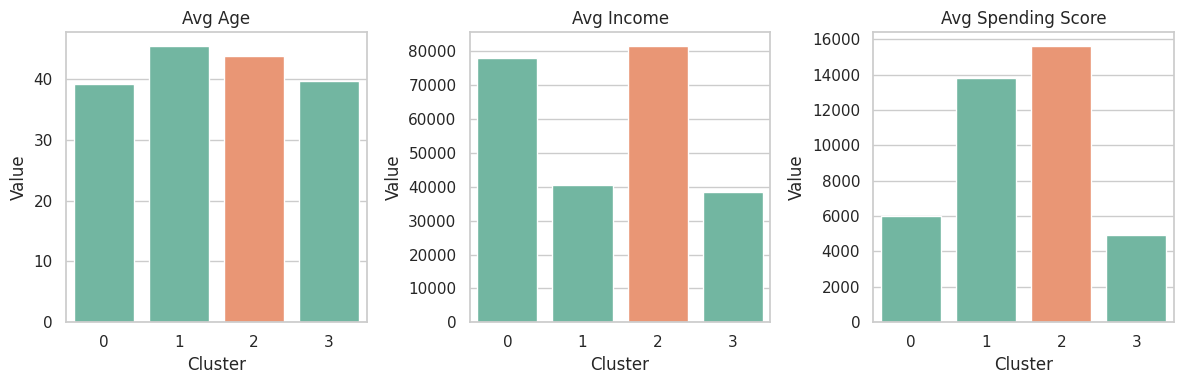

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

metrics = ["avg_age", "avg_income", "avg_spending_score"]
plt.figure(figsize=(12, 4))

for i, metric in enumerate(metrics, 1):
    plt.subplot(1, 3, i)
    sns.barplot(
        x="cluster",
        y=metric,
        data=cluster_summary,
        palette="Set2",
        hue="interpretation",
        legend=False  # avoid the future warning
    )
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("Cluster")
    plt.ylabel("Value")

plt.tight_layout()
plt.show()


**4. Gender Distribution per Cluster (Stacked Bar)**

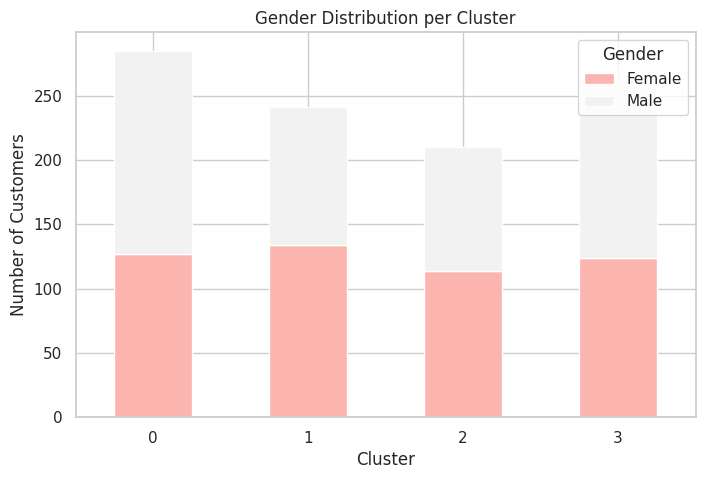

In [33]:
# Count male/female per cluster
gender_counts = df.groupby(["cluster", "gender"]).size().unstack(fill_value=0)

# Plot stacked bar
gender_counts.plot(kind="bar", stacked=True, figsize=(8,5), colormap="Pastel1")
plt.title("Gender Distribution per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.show()


###**6. Hierarchical Clustering**

####**6.1 Why Hierarchical Clustering?**

Hierarchical clustering is a **different way to group data** compared to K-Means. Its advantages:

**1. No need to predefine K**

- You don’t have to pick the number of clusters in advance.

- You can explore the data first and decide later.

**2. Tree-based understanding of similarity**

- Clusters are built as a tree, showing how points merge or split.

- Gives a visual hierarchy of relationships between data points.

**Intuition:**
- It’s like grouping friends by closeness:

- Start with each person alone

- Merge the most similar pairs

- Keep merging until everyone is in one big group

####**6.2 How It Works**

Two main approaches:

**1. Agglomerative (Bottom-Up)**

    - Start with each data point as its own cluster

    - Iteratively merge the two closest clusters

    - Stop when desired number of clusters is reached or tree is complete

**2. Divisive (Top-Down)**

    - Start with all points in one big cluster

    - Iteratively split clusters until each point is its own cluster

    - Most common in practice: Agglomerative clustering

**Linkage Methods**

When merging clusters, you need a rule for “**distance between clusters**”:

| Method   | How It Measures Distance            | Intuition                                         |
| -------- | ----------------------------------- | ------------------------------------------------- |
| Single   | Distance between closest points     | Can create “chained” clusters, sensitive to noise |
| Complete | Distance between farthest points    | Produces compact, evenly sized clusters           |
| Average  | Average distance between all points | Balanced, smoother clustering                     |


>Choice of linkage affects cluster shapes — just like K-Means assumptions.

####**6.3 Dendrograms Explained**

A **dendrogram** is the tree visualization of hierarchical clustering.

**How to Read**

- Leaves at the bottom → individual points

- Branches → merges of clusters

- Height → distance at which clusters merged (higher = less similar)

**How to Cut Clusters**

- Draw a **horizontal line** across the dendrogram

- Count how many vertical lines it intersects → this is the number of clusters

- The higher you cut → fewer, broader clusters

- The lower you cut → more, finer clusters

**Intuition:**
The dendrogram shows **all possible clusterings** at once. You pick the level that makes sense for your business.

**Hands-On: Build a Dendrogram**

Assume we use the same **customer features** as before:

**Notes:**

- `method='ward'` is common for numeric data, similar to K-Means assumptions

- `distance_sort='descending'` makes big merges appear at the top


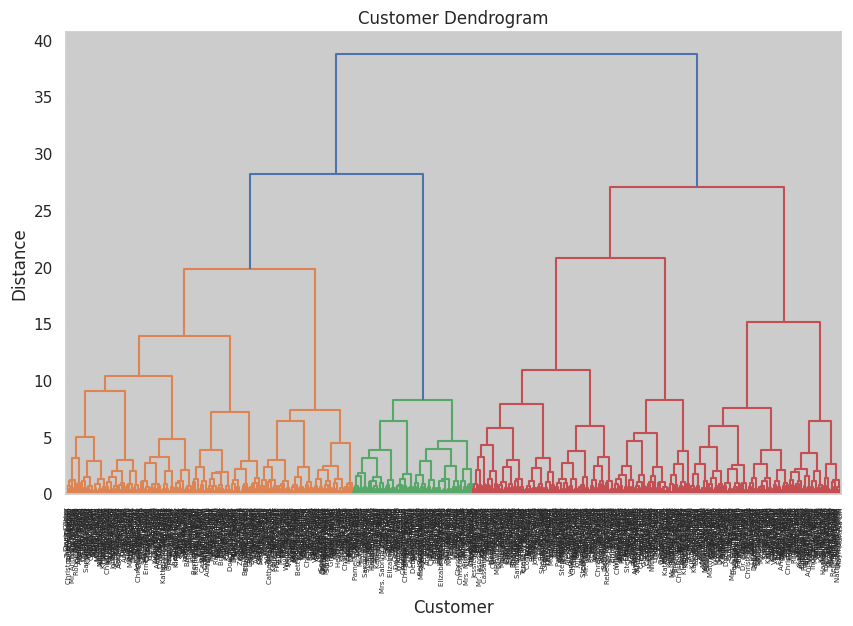

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

# Select numeric features for clustering
features = ["age", "income", "spending"]
X = df[features]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compute hierarchical clustering
linked = linkage(X_scaled, method='ward')  # Ward minimizes variance

# Plot dendrogram
plt.figure(figsize=(10, 6))
dendrogram(
    linked,
    labels=df['name'].values,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=False
)
plt.title("Customer Dendrogram")
plt.xlabel("Customer")
plt.ylabel("Distance")
plt.show()


**Key Observations**

At the very top, around distance **≈ 40, everything merges into one cluster**.

That top merge tells us:

>There are three very different major customer groups in this data.
- **Left branch(orange)**
- **Middle banch(green)**
- **Right branch(red)**

**Cut at distance ≈ 20–25**

If you draw a horizontal line around $20–25$, you get about $4–5$ clusters.

**Compare Results with K-Means**

1. **K-Means:** predefined K, centroid-based, assumes spherical clusters

2. **Hierarchical:** explores structure first, shows cluster hierarchy, flexible number of clusters

In [40]:
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import fcluster

# Example: KMeans with K=5
kmeans = KMeans(n_clusters=4, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# Compare with hierarchical clusters (choose 5 clusters)

df['hier_cluster'] = fcluster(linked, 4, criterion='maxclust')

# Compare assignments
pd.crosstab(df['kmeans_cluster'], df['hier_cluster'])


hier_cluster,1,2,3,4
kmeans_cluster,,,,
0,0,102,0,142
1,72,169,7,0
2,2,9,147,129
3,121,0,1,99


**How to Read the Table**

- **Rows** → K-Means clusters

- **Columns** → Hierarchical clusters

- **Values** → number of shared data points

**Clear Matches (Strong Agreement)**
Stable Segments:

- K-Means 0 ↔ Hierarchical 4 → 142 customers

- K-Means 1 ↔ Hierarchical 2 → 169 customers

- K-Means 2 ↔ Hierarchical 3 → 147 customers

- K-Means 3 ↔ Hierarchical 1 → 121 customers

These pairs represent **stable customer segments** detected by both methods.

**Notable Split**

| Hierarchical Cluster | K-Means Clusters & Counts                        | Observation                                                                       |
| -------------------- | ------------------------------------------------ | --------------------------------------------------------------------------------- |
| 1                    | K-Means 3 → 121, K-Means 1 → 72                  | K-Means splits these customers into two clusters; Hierarchical merges them        |
| 2                    | K-Means 0 → 102, K-Means 1 → 169, K-Means 2 → 9  | K-Means splits into three clusters; Hierarchical sees them as more similar        |
| 4                    | K-Means 0 → 142, K-Means 2 → 129, K-Means 3 → 99 | K-Means separates into three clusters; Hierarchical merges into one broader group |


These splits show that **K-Means captures finer distinctions**, dividing similar customers into multiple clusters, while **Hierarchical clustering** groups them more broadly, identifying higher-level patterns.

**Cutting the dendrogram** at four clusters produces a high-level grouping that largely aligns with **K-Means** clusters. In some cases, it merges two K-Means clusters into a single hierarchical group, indicating that these customer segments are similar at a broader level.

### **7. Comparing Clustering Methods**

####**7.1 K-Means vs Hierarchical**

<table style="width:100%; border-collapse: collapse; font-family: sans-serif;">
  <thead>
    <tr style="background-color: #f2f2f2; text-align: left;">
      <th style="border: 1px solid #ddd; padding: 12px;">Feature</th>
      <th style="border: 1px solid #ddd; padding: 12px;">K-Means Clustering</th>
      <th style="border: 1px solid #ddd; padding: 12px;">Hierarchical Clustering</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border: 1px solid #ddd; padding: 12px; font-weight: bold;">Scalability</td>
      <td style="border: 1px solid #ddd; padding: 12px;">Very fast; scales well to large datasets.</td>
      <td style="border: 1px solid #ddd; padding: 12px;">Computationally expensive; best for small to medium data.</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ddd; padding: 12px; font-weight: bold;">Interpretability</td>
      <td style="border: 1px solid #ddd; padding: 12px;">Easy to explain using centroids and averages.</td>
      <td style="border: 1px solid #ddd; padding: 12px;">Very intuitive visually through <strong>dendrograms</strong>.</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ddd; padding: 12px; font-weight: bold;">Stability</td>
      <td style="border: 1px solid #ddd; padding: 12px;">Can vary based on initialization and the choice of <em>K</em>.</td>
      <td style="border: 1px solid #ddd; padding: 12px;">Deterministic (produces the same result every run).</td>
    </tr>
  </tbody>
</table>

####**7.2 When to Use Which (Finance Context)**

<table style="width:100%; border-collapse: collapse; font-family: 'Segoe UI', Tahoma, Geneva, sans-serif; border: 1px solid #2c3e50;">
  <thead>
    <tr style="background-color: #2c3e50; color: white; text-align: left;">
      <th style="padding: 15px; border: 1px solid #34495e;">Finance Use Case</th>
      <th style="padding: 15px; border: 1px solid #34495e;">Recommended Method</th>
      <th style="padding: 15px; border: 1px solid #34495e;">Strategic Rationale</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 12px; border: 1px solid #ddd; font-weight: bold;">Large Transaction Logs</td>
      <td style="padding: 12px; border: 1px solid #ddd; background-color: #f9f9f9;">K-Means</td>
      <td style="padding: 12px; border: 1px solid #ddd;">Optimized for millions of rows; ideal for real-time fraud detection or batch processing.</td>
    </tr>
    <tr>
      <td style="padding: 12px; border: 1px solid #ddd; font-weight: bold;">Small Customer Cohorts</td>
      <td style="padding: 12px; border: 1px solid #ddd;">Hierarchical</td>
      <td style="padding: 12px; border: 1px solid #ddd;">Best for deep-dives into high-net-worth individual (HNWI) segments where similarity matters more than speed.</td>
    </tr>
    <tr>
      <td style="padding: 12px; border: 1px solid #ddd; font-weight: bold;">Exploratory Phase</td>
      <td style="padding: 12px; border: 1px solid #ddd; background-color: #f9f9f9;">Hierarchical</td>
      <td style="padding: 12px; border: 1px solid #ddd;">Use first to discover the natural number of segments without predefining <em>K</em>.</td>
    </tr>
    <tr>
      <td style="padding: 12px; border: 1px solid #ddd; font-weight: bold;">Production Deployment</td>
      <td style="padding: 12px; border: 1px solid #ddd;">K-Means</td>
      <td style="padding: 12px; border: 1px solid #ddd;">Lightweight and easy to deploy into production pipelines for automated credit scoring.</td>
    </tr>
  </tbody>
</table>

####**7.3 Validation Without Labels**

<table style="width:100%; border-collapse: collapse; font-family: Arial, sans-serif; border: 1px solid #dfe6e9;">
  <thead>
    <tr style="background-color: #0984e3; color: white; text-align: left;">
      <th style="padding: 12px; border: 1px solid #74b9ff;">Evaluation Metric</th>
      <th style="padding: 12px; border: 1px solid #74b9ff;">Focus Area</th>
      <th style="padding: 12px; border: 1px solid #74b9ff;">Success Criteria</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 10px; border: 1px solid #dfe6e9; font-weight: bold;">Silhouette Score</td>
      <td style="padding: 10px; border: 1px solid #dfe6e9;">Internal Cohesion</td>
      <td style="padding: 10px; border: 1px solid #dfe6e9;">A high score indicates points are close to their own cluster and far from others.</td>
    </tr>
    <tr>
      <td style="padding: 10px; border: 1px solid #dfe6e9; font-weight: bold; background-color: #f1f2f6;">Stability Checks</td>
      <td style="padding: 10px; border: 1px solid #dfe6e9; background-color: #f1f2f6;">Reliability</td>
      <td style="padding: 10px; border: 1px solid #dfe6e9; background-color: #f1f2f6;">Clusters remain consistent across different data samples or random seeds.</td>
    </tr>
    <tr>
      <td style="padding: 10px; border: 1px solid #dfe6e9; font-weight: bold;">Domain Validation</td>
      <td style="padding: 10px; border: 1px solid #dfe6e9;">Business Actionability</td>
      <td style="padding: 10px; border: 1px solid #dfe6e9;">Segments align with market logic and can be targeted by specific business strategies.</td>
    </tr>
  </tbody>
</table>

**Hands-on Discussion (What Makes More Sense?)**

- If clusters are consistent across both methods, trust the segment.

- Use Hierarchical to decide how many clusters exist.

- Use K-Means to operationalize those clusters at scale.

**Rule of thumb:**

- Hierarchical clustering helps you understand the data.
- K-Means helps you run the business.

###**8. Dimensionality Reduction (Why and When)**


####**8.1 The Curse of Dimensionality**

**Why distance breaks**

- In high dimensions, all points become similarly distant.

- Distance-based models (K-Means, Hierarchical) lose meaning.

**Noise vs signal**

- Many features add noise, not information.

- Models struggle to see real structure when noise dominates.

**Bottom line:**
- More features ≠ better clustering.

####**8.2 Principal Component Analysis (PCA)**

**PCA** is a linear transformation technique that identifies new axes (principal components) along which the data exhibits maximum variance. These components are ordered by the amount of variance they explain.

**Dimensionality reduction**

- Original features are compressed into a smaller set of components.

- Most of the data’s structural information is retained with fewer dimensions.

**What PCA preserves**

- Overall variance and global patterns

- Dominant relationships among features

**What PCA discards**

- Feature-level interpretability

- Minor or localized variations

####**8.3 PCA for Visualization vs Modeling**

**Visualization**

- Reduce data to 2 or 3 principal components.

- Enables visual inspection of cluster separation.

- Useful for exploratory analysis and validation.

**Modeling**

- Reduce data to an optimal number of components based on explained variance.

- Improves computational efficiency.

- Reduces noise, leading to more stable clustering results.

**Key takeaway:**
Dimensionality reduction, particularly PCA, enhances clustering effectiveness while improving interpretability and computational efficiency.

**Practical Workflow**

- Standardize numerical transaction features

- Apply PCA to the standardized data

- Select the number of components using explained variance

- Perform clustering on the reduced feature space

- Visualize clusters using the first two principal components

**1. Prepare Data**

In [41]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Select numerical features used for clustering
features = ["age", "purchase_frequency","income", "spending"]

X = df[features]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


**2. Apply PCA**

In [42]:
from sklearn.decomposition import PCA

# Keep enough components to explain ~90–95% variance
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df = df.copy()  # safety
df["pca_1"] = X_pca[:, 0]
df["pca_2"] = X_pca[:, 1]

print("Number of components:", pca.n_components_)
print("Explained variance ratio:", pca.explained_variance_ratio_)


Number of components: 3
Explained variance ratio: [0.48520819 0.26192438 0.23446463]


**PCA** retained three components to satisfy the variance threshold. For visualization, only the first two principal components were plotted to enable 2D inspection of cluster separation.

**4. K-Means on PCA Space**

In [43]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster"] = kmeans.fit_predict(X_pca)
df


,name,age,gender,education,income,country,purchase_frequency,spending,cluster,kmeans_cluster,hier_cluster,pca_1,pca_2
0,Teresa Williams MD,42,Female,High School,53936,Slovenia,0.9,13227.120,2,0,2,1.266273,-0.081795
1,Christine Myers,49,Female,Master,82468,Aruba,0.6,12674.040,0,0,2,0.701738,0.371163
2,Dwayne Moreno,55,Male,Bachelor,56941,Cyprus,0.3,5354.115,3,3,1,-0.984964,-0.803763
3,Amy Norton,24,Female,Bachelor,60651,Palau,0.2,2606.510,1,2,4,-1.977845,0.830040
4,Tonya Adams,64,Male,Master,81884,Zambia,0.9,18984.780,0,0,2,2.426506,-0.312229
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Jason Haas,42,Female,PhD,98170,Bosnia and Herzegovina,0.7,17435.950,0,0,4,1.526651,1.234922
996,Sharon Valdez,39,Male,High School,59174,Eritrea,0.9,11662.830,0,0,4,1.048033,0.231091
997,Andrew Taylor,50,Male,Master,59808,Serbia,0.4,7196.160,3,3,1,-0.565001,-0.437656
998,Jessica Johnson,50,Female,Master,58272,Cyprus,0.7,13939.520,2,1,2,1.008751,-0.402760


**5. Visualize Clusters in PCA Space**

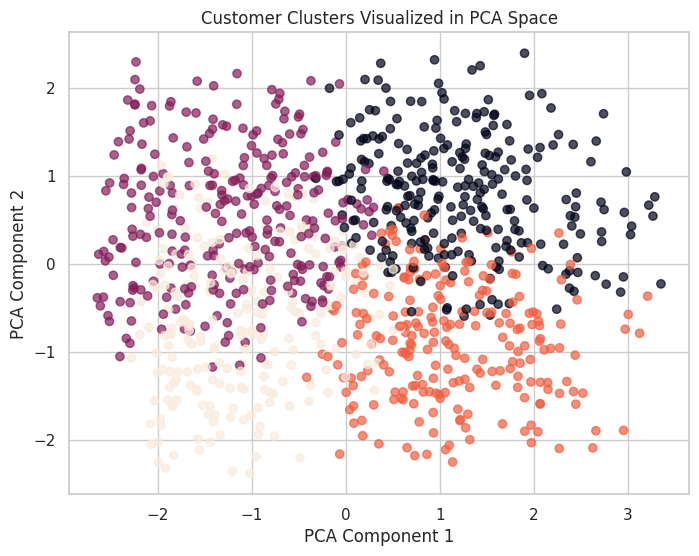

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df["pca_1"], df["pca_2"], c=df["cluster"], alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Clusters Visualized in PCA Space")
plt.show()


**Observations:**

**Distinct Clusters**

- There are four visually distinct clusters.

- The separation along PCA Component 1 and PCA Component 2 is fairly clear, indicating that the clusters are well-defined in the main directions of variance.

**Cluster Overlaps**

- Some clusters (like the lighter purple and dark purple) have minor overlaps, suggesting those customers have similar profiles.

- This could correspond to the splits seen between K-Means and Hierarchical clustering, where some customers are grouped differently depending on the algorithm.

**Cluster Compactness**

- The red cluster in the bottom-right is tight and compact, which usually indicates a well-defined, homogeneous segment.

- Other clusters (top-left) are slightly more spread out, suggesting more diversity in that segment.

**Interpretation:**

- The PCA visualization confirms that clusters capture meaningful separation in the data.

- It also helps identify borderline customers who might fall between two clusters, which aligns with your cross-tab of K-Means vs Hierarchical clusters.

- This is useful for reporting because stakeholders can visually see which customer segments are well-defined and which are more fluid.